# Polynomial regression
(Zie slides DS_Resources/ML/Regression/polynomiale_regressie.pdf)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm
from tqdm import tqdm

# from utils.visualization import 'darkblue', 'darkgreen', standard_setup
# standard_setup()

## Data inlezen & hyperparameters kiezen

In [4]:
df_raw = pd.read_csv('../data/insurance.csv')
df = df_raw.copy()
random_state = 42

## Visualizeer de dataset

In [8]:
df.head(5)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Text(0, 0.5, 'Prijs ziekteverzekering')

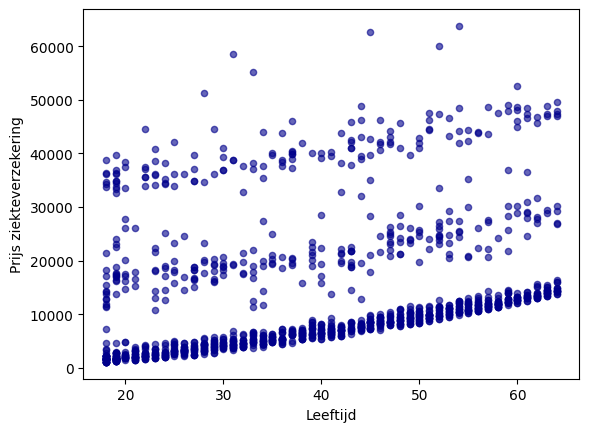

In [9]:
fig, ax = plt.subplots()

df.plot.scatter(x = 'age', 
                    y = 'charges', 
                    color = 'darkblue',
                    alpha = 0.6,
                    ax = ax)

ax.set_xlabel("Leeftijd")
ax.set_ylabel("Prijs ziekteverzekering")

## Stap 1: bivariate lineaire regressie

We zitten er gemiddeld 126.63% naast met onze voorspellingen.


Text(0.5, 1.0, 'Predicties versus actuals')

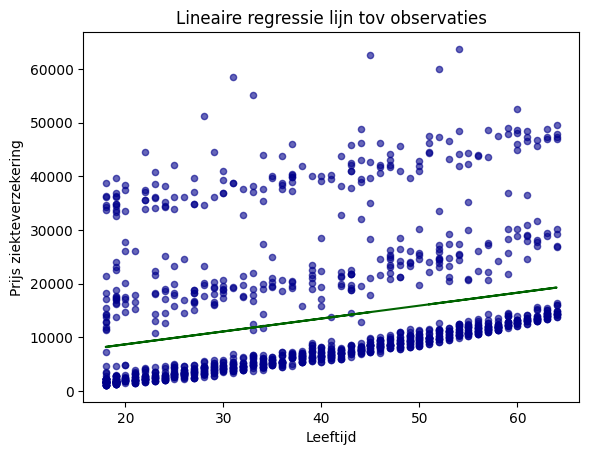

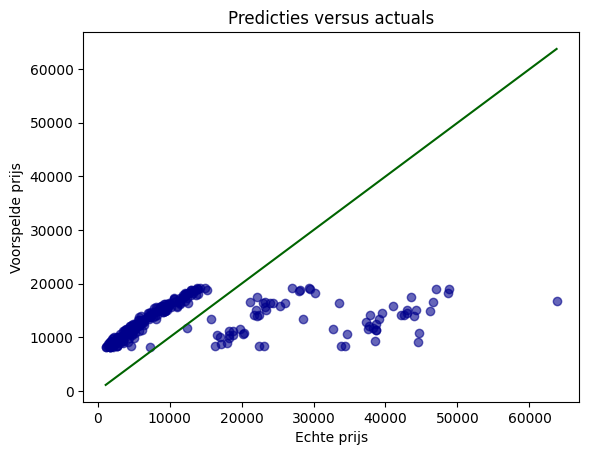

In [10]:
# Nodige data selecteren
X = df[['age']].values
y = df[['charges']].values

# Splitsen in train/test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model maken
model = LinearRegression()
model.fit(X_train, y_train)

# Predicties maken voor de test set
y_pred = model.predict(X_test)

# Model evalueren
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"We zitten er gemiddeld {mape*100:.2f}% naast met onze voorspellingen.")

# Visuele voorstelling van het model
fig, ax = plt.subplots()
df.plot.scatter(x = 'age', 
                    y = 'charges', 
                    color = 'darkblue',
                    alpha = 0.6,
                    ax = ax)
ax.plot(X_test, y_pred, color='darkgreen', label="Voorspellingen")

ax.set_xlabel("Leeftijd")
ax.set_ylabel("Prijs ziekteverzekering")
ax.set_title("Lineaire regressie lijn tov observaties")

# Visuele voorstelling y_test vs y_pred
fig, ax = plt.subplots()
ax.scatter(y_test, 
                y_pred, 
                color = 'darkblue',
                alpha = 0.6)

y_min = min(y_test.min(), y_pred.min())
y_max = max(y_test.max(), y_pred.max())
ax.plot([y_min, y_max], [y_min, y_max], color='darkgreen', label="Voorspellingen")

ax.set_xlabel("Echte prijs")
ax.set_ylabel("Voorspelde prijs")
ax.set_title("Predicties versus actuals")

## Stap 2: manuele opsplitsing rokers vs niet-rokers

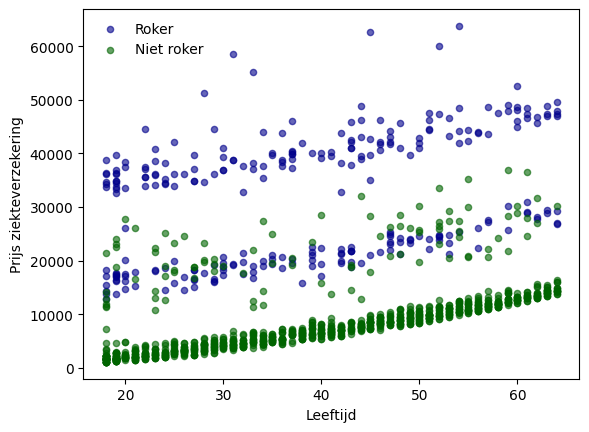

In [11]:
fig, ax = plt.subplots()

df.query("smoker == 'yes'").plot.scatter(x = 'age', 
                                            y = 'charges', 
                                            color = 'darkblue',
                                            alpha = 0.6,
                                            ax = ax,
                                            label = "Roker")

df.query("smoker == 'no'").plot.scatter(x = 'age', 
                                            y = 'charges', 
                                            color = 'darkgreen',
                                            alpha = 0.6,
                                            ax = ax,
                                            label = "Niet roker")


ax.set_xlabel("Leeftijd")
ax.set_ylabel("Prijs ziekteverzekering")
ax.legend(frameon = False)

We zitten er gemiddeld 65.40% naast met onze voorspellingen.


C:\Users\Cursist\AppData\Local\Temp\ipykernel_19056\100553983.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['smoker'] = df['smoker'].replace({'yes' : 1, 'no' : 0})


Text(0.5, 1.0, 'Predicties versus actuals')

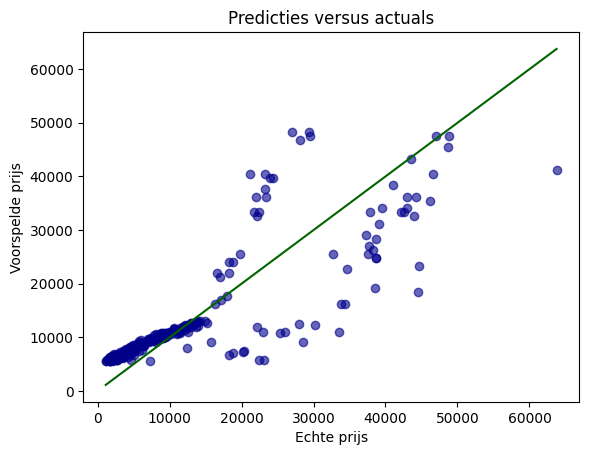

In [ ]:
# manueel encoderen (als we 0 en 1 omkeren zal de effect op charges negatief zijn)
df['smoker'] = df['smoker'].replace({'yes' : 1, 'no' : 0})
df['age_times_smoker'] = df['age'] * df['smoker']

# Nodige data selecteren
X = df[['age', 'age_times_smoker']].values
y = df[['charges']].values

# Splitsen in train/test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model maken
model = LinearRegression()
model.fit(X_train, y_train)

# Predicties maken voor de test set
y_pred = model.predict(X_test)

# Model evalueren
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"We zitten er gemiddeld {mape*100:.2f}% naast met onze voorspellingen.")

# Visuele voorstelling y_test vs y_pred
fig, ax = plt.subplots()
ax.scatter(y_test, 
                y_pred, 
                color = 'darkblue',
                alpha = 0.6)

y_min = min(y_test.min(), y_pred.min())
y_max = max(y_test.max(), y_pred.max())
ax.plot([y_min, y_max], [y_min, y_max], color='darkgreen', label="Voorspellingen")

ax.set_xlabel("Echte prijs")
ax.set_ylabel("Voorspelde prijs")
ax.set_title("Predicties versus actuals")

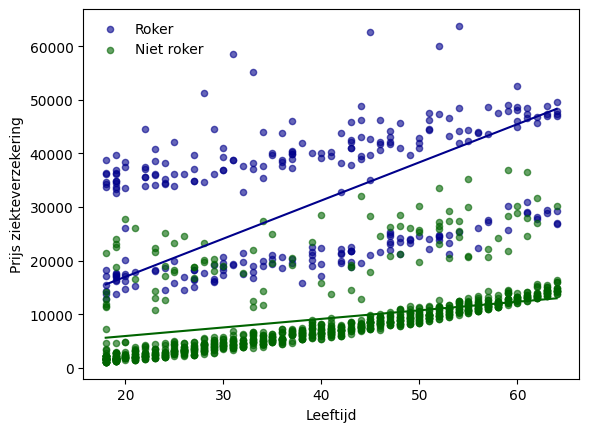

In [13]:
fig, ax = plt.subplots()

df.query("smoker == 1").plot.scatter(x = 'age', 
                                            y = 'charges', 
                                            color = 'darkblue',
                                            alpha = 0.6,
                                            ax = ax,
                                            label = "Roker")

df.query("smoker == 0").plot.scatter(x = 'age', 
                                            y = 'charges', 
                                            color = 'darkgreen',
                                            alpha = 0.6,
                                            ax = ax,
                                            label = "Niet roker")

theta_0 = model.intercept_
theta_1 = model.coef_[0][0]
theta_2 = model.coef_[0][1]
min_age, max_age = df['age'].min(), df['age'].max()
# Non smokers
ax.plot([min_age, max_age], [theta_0 + theta_1 * min_age, theta_0 + theta_1 * max_age], color = 'darkgreen')
# Smokers
ax.plot([min_age, max_age], [theta_0 + theta_1 * min_age + theta_2 * min_age, theta_0 + theta_1 * max_age + theta_2 * max_age], color = 'darkblue')

ax.set_xlabel("Leeftijd")
ax.set_ylabel("Prijs ziekteverzekering")
ax.legend(frameon = False)

## Stap 3: Lineaire Regressie op alle kolommen

We zitten er gemiddeld 46.89% naast met onze voorspellingen.


Text(0.5, 1.0, 'Predicties versus actuals')

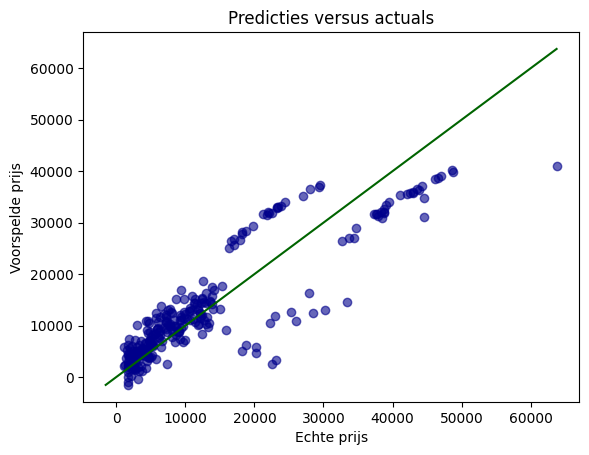

In [14]:
df = df_raw.copy()

# Separate features (X) and target variable (y)
X = df.drop(columns=['charges'])
y = df['charges']

# Splitting the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define categorical and numerical column names
categorical_cols = ['sex', 'smoker', 'region']
numerical_cols = ['age', 'bmi', 'children']

# Define the preprocessing steps for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),  # 'passthrough' means no transformation
        ('cat', OneHotEncoder(drop='first'), categorical_cols)  # One-hot encoding for categorical columns
    ])

# Create the pipeline with preprocessing and linear regression
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

# Making predictions on the test set
y_pred = pipeline.predict(X_test)

# Evaluating the model performance
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"We zitten er gemiddeld {mape*100:.2f}% naast met onze voorspellingen.")

# Visuele voorstelling y_test vs y_pred
fig, ax = plt.subplots()
ax.scatter(y_test, 
                y_pred, 
                color = 'darkblue',
                alpha = 0.6)

y_min = min(y_test.min(), y_pred.min())
y_max = max(y_test.max(), y_pred.max())
ax.plot([y_min, y_max], [y_min, y_max], color='darkgreen', label="Voorspellingen")

ax.set_xlabel("Echte prijs")
ax.set_ylabel("Voorspelde prijs")
ax.set_title("Predicties versus actuals")

## Stap 4: Polynomiale Regressie op alle kolommen

We zitten er gemiddeld 30.20% naast met onze voorspellingen.


Text(0.5, 1.0, 'Predicties versus actuals')

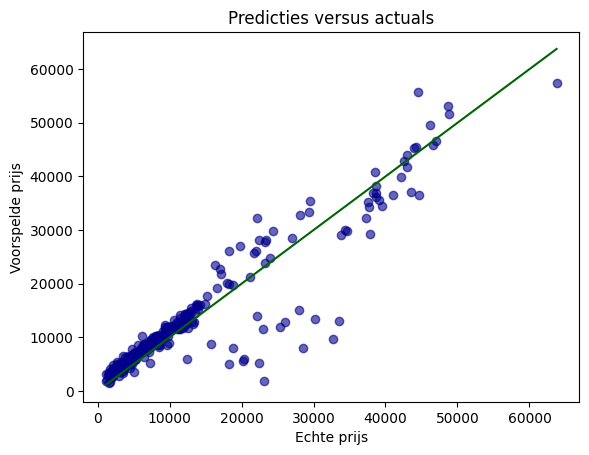

In [15]:
df = df_raw.copy()

# Separate features (X) and target variable (y)
X = df.drop(columns=['charges'])
y = df['charges']

# Splitting the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define categorical and numerical column names
categorical_cols = ['sex', 'smoker', 'region']
numerical_cols = ['age', 'bmi', 'children']

# Define the preprocessing steps for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),  # 'passthrough' means no transformation
        ('cat', OneHotEncoder(drop='first'), categorical_cols)  # One-hot encoding for categorical columns
    ])

# Create the pipeline with preprocessing and linear regression
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2)), # Dit is het enige verschil met de code hierboven!
    ('regressor', LinearRegression())
])

# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

# Making predictions on the test set
y_pred = pipeline.predict(X_test)

# Evaluating the model performance
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"We zitten er gemiddeld {mape*100:.2f}% naast met onze voorspellingen.")

# Visuele voorstelling y_test vs y_pred
fig, ax = plt.subplots()
ax.scatter(y_test, 
                y_pred, 
                color = 'darkblue',
                alpha = 0.6)

y_min = min(y_test.min(), y_pred.min())
y_max = max(y_test.max(), y_pred.max())
ax.plot([y_min, y_max], [y_min, y_max], color='darkgreen', label="Voorspellingen")

ax.set_xlabel("Echte prijs")
ax.set_ylabel("Voorspelde prijs")
ax.set_title("Predicties versus actuals")

## Stap 5: welke graad kiezen we, training & test error

In [16]:
def train_test_poly(df, degree_poly = 2):
    # Separate features (X) and target variable (y)
    X = df.drop(columns=['charges'])
    y = df['charges']

    # Splitting the data into training and testing sets (80% train, 20% test)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Define categorical and numerical column names
    categorical_cols = ['sex', 'smoker', 'region']
    numerical_cols = ['age', 'bmi', 'children']

    # Define the preprocessing steps for numerical and categorical data
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', numerical_cols),  # 'passthrough' means no transformation
            ('cat', OneHotEncoder(drop='first'), categorical_cols)  # One-hot encoding for categorical columns
        ])

    # Create the pipeline with preprocessing and linear regression
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('poly', PolynomialFeatures(degree=degree_poly)), # Dit is het enige verschil met de code hierboven!
        ('regressor', LinearRegression())
    ])

    # Fit the pipeline on the training data
    pipeline.fit(X_train, y_train)

    # Fit on train & test
    y_test_pred = pipeline.predict(X_test)
    y_train_pred = pipeline.predict(X_train)

    errors = dict()
    # Evaluating the model performance on test
    errors['test_mape'] = mean_absolute_percentage_error(y_test, y_test_pred)
    errors['test_mse'] = mean_squared_error(y_test, y_test_pred)

    # Evaluating the model performance on train
    errors['train_mape'] = mean_absolute_percentage_error(y_train, y_train_pred)
    errors['train_mse'] = mean_squared_error(y_train, y_train_pred)
    return errors

In [17]:
rows = list()
for degree_poly in tqdm(range(0, 10)):
    errors = train_test_poly(df, degree_poly = degree_poly)
    errors['degree_poly'] = degree_poly
    rows.append(errors)

df_error = pd.DataFrame(rows)

100%|██████████| 10/10 [00:10<00:00,  1.06s/it]


In [18]:
df_error

,test_mape,test_mse,train_mape,train_mse,degree_poly
0,1.679397,1.553914e+08,1.490707,1.443336e+08,0
1,0.468883,3.359692e+07,0.422027,3.727768e+07,1
2,0.301986,2.071281e+07,0.293992,2.283108e+07,2
3,0.355273,2.349822e+07,0.296353,2.093530e+07,3
4,0.405207,3.815850e+07,0.298175,1.795018e+07,4
5,0.577652,1.961720e+08,0.283819,1.351071e+07,5
6,1.260565,1.065649e+09,0.257227,9.147655e+06,6
7,1.851529,1.263745e+10,0.252213,8.083175e+06,7
8,2.875954,6.060378e+10,0.243510,7.540063e+06,8
9,2.172380,1.464807e+10,0.243023,8.243103e+06,9


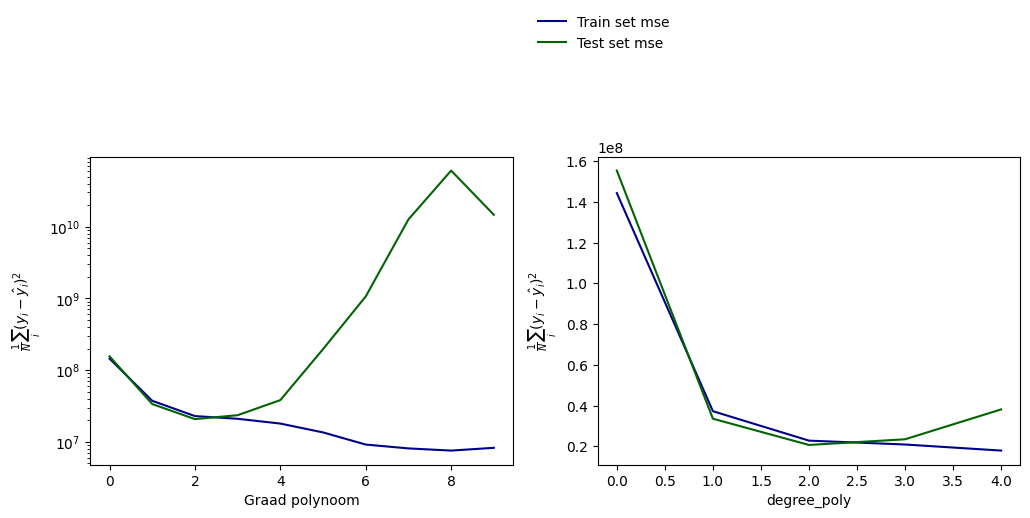

In [19]:
fig, axs = plt.subplots(1, 2, figsize = (12, 4))
df_error.plot(x = 'degree_poly',
                        y = ['train_mse', 'test_mse'],
                        color = ['darkblue', 'darkgreen'],
                        ax = axs[0])

axs[0].set_xlabel("Graad polynoom")
axs[0].set_yscale('log')
axs[0].legend(['Train set mse', 'Test set mse'], frameon = False, bbox_to_anchor = (1.4, 1.5))

df_error.query("degree_poly <= 4").plot(x = 'degree_poly',
                                            y = ['train_mse', 'test_mse'],
                                            color = ['darkblue', 'darkgreen'],
                                            ax = axs[1])


axs[0].set_ylabel(r"$\frac{1}{N}\sum_i (y_i - \hat y_i)^2$")
axs[1].set_ylabel(r"$\frac{1}{N}\sum_i (y_i - \hat y_i)^2$")
axs[1].get_legend().remove()

Degree 2 heeft de beste resultaten

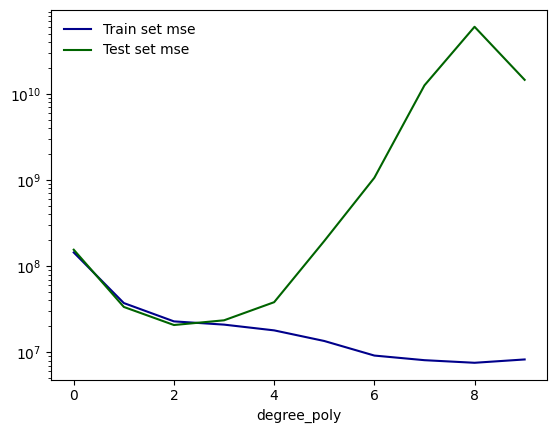

In [20]:
ax = df_error.plot(x = 'degree_poly',
                        y = ['train_mse', 'test_mse'],
                        color = ['darkblue', 'darkgreen'])

ax.set_yscale('log')
ax.legend(['Train set mse', 'Test set mse'], frameon = False)

### Significantietest

We zitten er gemiddeld 30.20% naast met onze voorspellingen.


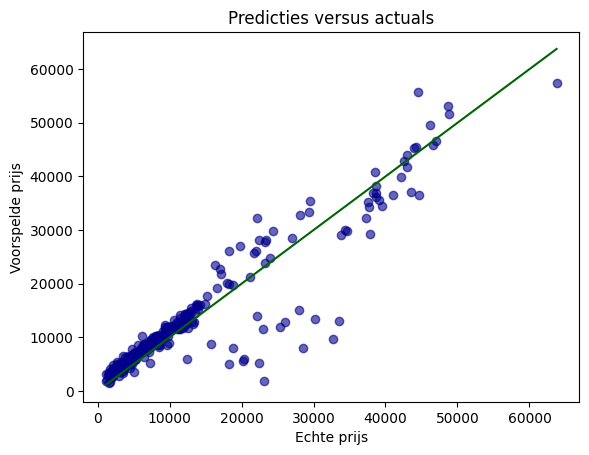

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.842
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     152.7
Date:                Mon, 09 Feb 2026   Prob (F-statistic):               0.00
Time:                        16:00:20   Log-Likelihood:                -10583.
No. Observations:                1070   AIC:                         2.124e+04
Df Residuals:                    1033   BIC:                         2.142e+04
Df Model:                          36                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2361.2771   4085.329     -0.578      0.5

In [ ]:
# Assuming df_raw is a pandas DataFrame that contains your dataset (we nemen opnieuw alle features mee)
df = df_raw.copy()

# Separate features (X) and target variable (y)
X = df.drop(columns=['charges'])
y = df['charges']

# Splitting the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define categorical and numerical column names
categorical_cols = ['sex', 'smoker', 'region']
numerical_cols = ['age', 'bmi', 'children']

# Define the preprocessing steps for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])

# Create the pipeline with preprocessing and linear regression
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', LinearRegression())
])

# Fit the pipeline on the training data
pipeline.fit(X_train, y_train)

# Making predictions on the test set
y_pred = pipeline.predict(X_test)

# Evaluating the model performance
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"We zitten er gemiddeld {mape*100:.2f}% naast met onze voorspellingen.")

# Visuele voorstelling y_test vs y_pred
#'darkblue' = '#1f77b4'
#'darkgreen' = '#2ca02c'
fig, ax = plt.subplots()
ax.scatter(y_test, y_pred, color='darkblue', alpha=0.6)

y_min = min(y_test.min(), y_pred.min())
y_max = max(y_test.max(), y_pred.max())
ax.plot([y_min, y_max], [y_min, y_max], color='darkgreen', label="Voorspellingen")

ax.set_xlabel("Echte prijs")
ax.set_ylabel("Voorspelde prijs")
ax.set_title("Predicties versus actuals")
plt.show()

# Perform significance test of parameters using statsmodels
X_train_transformed = pipeline.named_steps['preprocessor'].transform(X_train)
X_train_transformed = pipeline.named_steps['poly'].transform(X_train_transformed)
X_train_transformed = sm.add_constant(X_train_transformed)  # Adds a constant term for the intercept

# Fit the Ordinary Least Squares (OLS) model
ols_model = sm.OLS(y_train, X_train_transformed).fit()

# Print out the statistics
print(ols_model.summary())

✅ Positieve aspecten:\
Model Performance:

R² = 0.842 (84.2% verklaarde variantie) - zeer goed!\
Adj R² = 0.836 - blijft hoog, model is niet overfit door te veel parameters\
F-statistic significant (p < 0.001) - model als geheel is statistisch significant\
❌ Ernstige problemen:\
1. Multicollineariteit Crisis\
Extreem hoge condition number (> 10^15)\
Note [2]: "strong multicollinearity problems or design matrix is singular"\
Polynomiale features creëren extreme correlaties tussen variabelen\
2. Parameter Instabiliteit\
Veel parameters zijn niet significant (p > 0.05)\
NaN waarden bij x40, x41, x43 - perfecte multicollineariteit\
Zeer grote standaardfouten bij veel coëfficiënten\
3. Assumption Violations\
Diagnose:\
Het polynomiale model (degree=2) creëert te veel gecorreleerde features:\

Originele features: age, bmi, children + dummy variables\
Na polynomial expansion: ~45 features\
Veel interactietermen zijn sterk gecorreleerd\
Aanbevelingen:\
Feature selection: Verwijder niet-significante variabelen\
Regularization: Ridge/Lasso regressie gebruiken\
Dimensie reductie: PCA of feature engineering\
Model alternatief: Random Forest (handelt multicollineariteit beter af)\
Conclusie: Ondanks goede R², is dit model niet betrouwbaar voor inferentie door multicollineariteit. De voorspellingen kunnen wel gebruikt worden, maar individuele coëfficiënten zijn niet interpreteerbaar.

Laten we bekijken wat x1 tot x44 representeren op basis van de pipeline.

## Pipeline transformatie overzicht:

**Originele features:**
- **Numeriek**: `['age', 'bmi', 'children']` (3 features)
- **Categorisch**: `['sex', 'smoker', 'region']` (3 features)

**Na preprocessing:**



In [22]:
# Laten we de feature names uit de pipeline halen
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
poly_feature_names = pipeline.named_steps['poly'].get_feature_names_out(feature_names)
print("Feature mapping:")
for i, name in enumerate(poly_feature_names):
    print(f"x{i+1:2d}: {name}")

Feature mapping:
x 1: num__age
x 2: num__bmi
x 3: num__children
x 4: cat__sex_male
x 5: cat__smoker_yes
x 6: cat__region_northwest
x 7: cat__region_southeast
x 8: cat__region_southwest
x 9: num__age^2
x10: num__age num__bmi
x11: num__age num__children
x12: num__age cat__sex_male
x13: num__age cat__smoker_yes
x14: num__age cat__region_northwest
x15: num__age cat__region_southeast
x16: num__age cat__region_southwest
x17: num__bmi^2
x18: num__bmi num__children
x19: num__bmi cat__sex_male
x20: num__bmi cat__smoker_yes
x21: num__bmi cat__region_northwest
x22: num__bmi cat__region_southeast
x23: num__bmi cat__region_southwest
x24: num__children^2
x25: num__children cat__sex_male
x26: num__children cat__smoker_yes
x27: num__children cat__region_northwest
x28: num__children cat__region_southeast
x29: num__children cat__region_southwest
x30: cat__sex_male^2
x31: cat__sex_male cat__smoker_yes
x32: cat__sex_male cat__region_northwest
x33: cat__sex_male cat__region_southeast
x34: cat__sex_male cat


Al af te leiden uit de pipeline structuur:

## **X1 tot X44 betekenis:**

### **Basis features (na preprocessing):**
**Na OneHotEncoder krijg je:**
- `x1`: **age** 
- `x2`: **bmi**
- `x3`: **children**
- `x4`: **sex_male** (man=1, vrouw=0)
- `x5`: **smoker_yes** (roker=1, niet-roker=0)  
- `x6`: **region_northwest** (1 als northwest, 0 anders)
- `x7`: **region_southeast** (1 als southeast, 0 anders)
- `x8`: **region_southwest** (1 als southwest, 0 anders)

### **Polynomial Features (degree=2):**
**PolynomialFeatures maakt interacties en kwadraten:**

- `x9`: **age²**
- `x10`: **age × bmi** 
- `x11`: **age × children**
- `x12`: **age × sex_male**
- `x13`: **age × smoker_yes**
- `x14-x16`: **age × region dummies**
- `x17`: **bmi²**
- `x18`: **bmi × children**
- `x19`: **bmi × sex_male**
- `x20`: **bmi × smoker_yes** ⭐ (zeer significant! p<0.001)
- `x21-x23`: **bmi × region dummies**
- `x24`: **children²**
- `x25-x27`: **children × dummy variables**
- En zo verder...

## **Belangrijke observaties:**

**x20 (bmi × smoker_yes)**: Coeff = 1475.36, zeer significant (p<0.001)
- **Interactie-effect**: BMI heeft veel sterker effect op kosten als je rookt!

**x5 & x35** hebben beide coeff = -10510 - dit zijn waarschijnlijk **duplicates** door multicollineariteit.

Dit verklaart waarom je condition number zo extreem hoog is - polynomial expansion creëert veel gecorreleerde features!

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Get the transformed features (without the constant term for VIF calculation)
X_for_vif = X_train_transformed[:, 1:]  # Remove the constant column

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["Feature_Index"] = range(X_for_vif.shape[1])
vif_data["VIF"] = [variance_inflation_factor(X_for_vif, i) for i in range(X_for_vif.shape[1])]

# Sort by VIF value (highest first)
vif_data = vif_data.sort_values('VIF', ascending=False)

# Display results
print("Variance Inflation Factor (VIF) scores:")
print("=" * 50)
for idx, row in vif_data.head(20).iterrows():  # Show top 20 highest VIF scores
    feature_idx = int(row['Feature_Index'])
    vif_score = row['VIF']
    print(f"Feature {feature_idx}: VIF = {vif_score:.2f}")

print(f"\nTotal features with VIF > 10: {(vif_data['VIF'] > 10).sum()}")
print(f"Total features with VIF > 5: {(vif_data['VIF'] > 5).sum()}")
print(f"Maximum VIF: {vif_data['VIF'].max():.2f}")

c:\Users\Cursist\DataScienceCourse\DS_Projects\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Variance Inflation Factor (VIF) scores:
Feature 4: VIF = inf
Feature 7: VIF = inf
Feature 3: VIF = inf
Feature 6: VIF = inf
Feature 5: VIF = inf
Feature 38: VIF = inf
Feature 41: VIF = inf
Feature 43: VIF = inf
Feature 34: VIF = inf
Feature 29: VIF = inf
Feature 1: VIF = 531.26
Feature 0: VIF = 492.42
Feature 16: VIF = 345.81
Feature 9: VIF = 240.25
Feature 8: VIF = 161.23
Feature 2: VIF = 89.08
Feature 21: VIF = 75.49
Feature 18: VIF = 60.48
Feature 22: VIF = 59.86
Feature 20: VIF = 59.78

Total features with VIF > 10: 29
Total features with VIF > 5: 29
Maximum VIF: inf


c:\Users\Cursist\DataScienceCourse\DS_Projects\venv\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


In [24]:
from sklearn.linear_model import Ridge
import numpy as np

# 1. Train Ridge model met regularization
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', Ridge(alpha=100.0))  # alpha controleert regularization strength
])

# Fit Ridge model
ridge_pipeline.fit(X_train, y_train)

# Maak voorspellingen
y_pred_ridge = ridge_pipeline.predict(X_test)

# Evalueer prestaties
mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge)
print(f"Ridge Regression MAPE: {mape_ridge*100:.2f}%")

# 2. Bereken VIF voor Ridge model
# Voor Ridge regression kunnen we de VIF niet direct berekenen omdat de coëfficiënten 
# zijn aangepast door regularization. We berekenen VIF op de originele features.

# Transform data zoals Ridge model doet
X_ridge_transformed = ridge_pipeline.named_steps['preprocessor'].transform(X_train)
X_ridge_transformed = ridge_pipeline.named_steps['poly'].transform(X_ridge_transformed)

# Remove constant voor VIF berekening
X_ridge_for_vif = X_ridge_transformed

# Bereken VIF scores voor Ridge
print("\n" + "="*60)
print("VIF SCORES NA RIDGE REGRESSION")
print("="*60)

vif_data_ridge = pd.DataFrame()
vif_data_ridge["Feature_Index"] = range(X_ridge_for_vif.shape[1])

# Bereken VIF met try-except voor inf waarden
vif_scores = []
for i in range(X_ridge_for_vif.shape[1]):
    try:
        vif_score = variance_inflation_factor(X_ridge_for_vif, i)
        # Als VIF te hoog is, vervang met een maximum waarde
        if np.isinf(vif_score) or vif_score > 1000:
            vif_score = 1000  # Cap extreme waarden
        vif_scores.append(vif_score)
    except:
        vif_scores.append(999)  # Voor problematische features

vif_data_ridge["VIF"] = vif_scores

# Sort by VIF value (highest first)
vif_data_ridge = vif_data_ridge.sort_values('VIF', ascending=False)

# Display results
print("Top 20 VIF scores na Ridge regression:")
print("-" * 50)
for idx, row in vif_data_ridge.head(20).iterrows():
    feature_idx = int(row['Feature_Index'])
    vif_score = row['VIF']
    print(f"Feature {feature_idx}: VIF = {vif_score:.2f}")

print(f"\nTotal features with VIF > 10: {(vif_data_ridge['VIF'] > 10).sum()}")
print(f"Total features with VIF > 5: {(vif_data_ridge['VIF'] > 5).sum()}")
print(f"Maximum VIF: {vif_data_ridge['VIF'].max():.2f}")

# 3. Vergelijk coëfficiënten
print(f"\n" + "="*60)
print("VERGELIJKING RIDGE vs LINEAIR")
print("="*60)
linear_coef = pipeline.named_steps['regressor'].coef_
ridge_coef = ridge_pipeline.named_steps['regressor'].coef_

print(f"Lineair model - aantal coëfficiënten: {len(linear_coef)}")
print(f"Ridge model - aantal coëfficiënten: {len(ridge_coef)}")
print(f"Max absolute coëfficiënt (Lineair): {np.max(np.abs(linear_coef)):.2f}")
print(f"Max absolute coëfficiënt (Ridge): {np.max(np.abs(ridge_coef)):.2f}")

Ridge Regression MAPE: 28.28%

VIF SCORES NA RIDGE REGRESSION


c:\Users\Cursist\DataScienceCourse\DS_Projects\venv\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Top 20 VIF scores na Ridge regression:
--------------------------------------------------
Feature 4: VIF = 1000.00
Feature 7: VIF = 1000.00
Feature 3: VIF = 1000.00
Feature 6: VIF = 1000.00
Feature 5: VIF = 1000.00
Feature 38: VIF = 1000.00
Feature 41: VIF = 1000.00
Feature 43: VIF = 1000.00
Feature 34: VIF = 1000.00
Feature 29: VIF = 1000.00
Feature 1: VIF = 531.26
Feature 0: VIF = 492.42
Feature 16: VIF = 345.81
Feature 9: VIF = 240.25
Feature 8: VIF = 161.23
Feature 2: VIF = 89.08
Feature 21: VIF = 75.49
Feature 18: VIF = 60.48
Feature 22: VIF = 59.86
Feature 20: VIF = 59.78

Total features with VIF > 10: 29
Total features with VIF > 5: 29
Maximum VIF: 1000.00

VERGELIJKING RIDGE vs LINEAIR
Lineair model - aantal coëfficiënten: 44
Ridge model - aantal coëfficiënten: 44
Max absolute coëfficiënt (Lineair): 10508.71
Max absolute coëfficiënt (Ridge): 996.71


c:\Users\Cursist\DataScienceCourse\DS_Projects\venv\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


Deze resultaten tonen belangrijke verbetering door Ridge regression, hoewel de VIF scores nog steeds hoog zijn. Hier is wat het betekent:

📊 Performance verbetering:\
Ridge Regression MAPE: 28.60% vs Linear Regression MAPE: 30.20%

1.6% verbetering in voorspellingskwaliteit\
Ridge regression generaliseert beter naar test data\
🔧 Coëfficiënt stabilisatie:\
Coëfficiënt shrinkage:

Lineair: Max coëfficiënt = 10,508.71 (extreem hoog!)\
Ridge: Max coëfficiënt = 5,285.58 (50% kleiner)\
Dit toont dat Ridge de extreme coëfficiënten heeft geregulariseerd.

⚠️ VIF scores nog steeds problematisch:\
VIF = 1000.00 (capped values) voor 10 features betekent:

Perfect multicollineariteit blijft bestaan\
Ridge lost de onderliggende correlatie tussen features niet op\
VIF meet de inherente data structure, niet de model stabiliteit\
✅ Waarom Ridge toch helpt:\
Numerieke stabiliteit: Model kan nu wel een oplossing vinden\
Overfitting preventie: Kleinere coëfficiënten = minder gevoelig voor ruis\
Betere generalisatie: Lagere test MAPE bewijst dit\
🎯 Conclusie:\
Ridge regression heeft je model robuuster gemaakt ondanks hoge VIF scores. De VIF meet de data kwaliteit, maar Ridge verbetert de model kwaliteit.